# Day 1 - 세션 2 : 1D-CNN으로 베어링 고장 분류하기

## 이 노트북에서 할 일

세션 1에서 만든 **전처리 데이터셋** (윈도우 슬라이싱 + FFT + 정규화)을 가지고,
**1D-CNN(1차원 합성곱 신경망)** 모델을 학습시켜
베어링 상태를 4가지 클래스(Normal / Inner Race / Outer Race / Ball)로 분류합니다.

## CNN이 하는 일 (복습)

- **필터(커널)** : 입력 신호에서 특정 파형 패턴을 탐지하는 탐지기. 여러 개를 사용해 여러 패턴을 동시에 탐지
- **Pooling** : 탐지 결과를 압축 (정확한 위치보다 "이런 패턴이 있었냐 없었냐"가 중요)
- **Flatten → Fully Connected** : 압축된 특징을 펼쳐서 4가지 클래스 중 하나로 분류

```
입력 (FFT 특징, 길이 1024)
        ↓
[Conv1d + ReLU + Pooling]  ← 1차 패턴 탐지
        ↓
[Conv1d + ReLU + Pooling]  ← 더 복잡한 패턴 탐지
        ↓
[Flatten → Fully Connected]
        ↓
Normal / Inner Race / Outer Race / Ball 중 하나
```

## 오늘의 목표

1. 세션 1의 전처리 파이프라인으로 학습 데이터 만들기
2. PyTorch로 1D-CNN 모델 설계하기
3. 모델 학습 + Loss 변화 관찰
4. **Accuracy**와 **Confusion Matrix**로 결과 해석하기 (어떤 오류가 현장에서 더 위험한가?)
5. 학습된 모델을 `.pt` 파일로 저장하기
6. 전체 과정을 함수로 묶어보기 (실습)

In [1]:
# 필요한 라이브러리 불러오기
import re
import platform

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

%matplotlib inline
# 그래프 한글 깨짐 방지 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위해 랜덤 시드 고정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 사용 가능한 GPU가 있으면 사용 (CUDA > MPS(Apple Silicon) > CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용할 디바이스: {device}")

사용할 디바이스: cpu


---
## STEP 1. 데이터 준비 - 세션 1 전처리 파이프라인 재사용

세션 1(`1. Data Preprocessing.ipynb`)에서 만든 함수들을 그대로 가져와서,
CWRU 데이터셋을 **FFT 특징(X)** 과 **클래스 레이블(y)** 로 변환합니다.

> 각 함수가 어떤 역할을 하는지는 세션 1 노트북에서 자세히 설명했으므로,
> 여기서는 코드만 재사용하고 핵심 주석만 남겨둡니다.

⚠️ **Data Leakage 방지를 위한 전처리 순서**

세션 1 STEP 5에서 설명한 것처럼, 윈도우는 50%씩 겹치도록(`step=1024`) 만들어집니다.
만약 "① 전체 신호를 윈도우로 자르고 → ② 그 윈도우들을 무작위로 train/test로 분리"하면,
서로 절반이 겹치는 윈도우가 한쪽은 train, 다른 쪽은 test에 들어갈 수 있어
**test 데이터가 train 데이터를 거의 그대로 미리 본 것과 같은 상태(Data Leakage)** 가 됩니다.

그래서 이번 노트북에서도 세션 1과 동일하게 다음 순서를 따릅니다.

```
파일별 원본 신호
   ↓ ① 시간 순서대로 train(앞 80%) / test(뒤 20%) 분리
   ↓ ② train/test 각각에 윈도우 슬라이싱 적용
   ↓ ③ 각 윈도우에 FFT 적용
   ↓ ④ train 통계로 정규화(StandardScaler) → train/test 모두 transform
```

In [2]:
def sliding_window(signal, window_size=2048, step=1024):
    """긴 신호를 (window_size) 크기의 여러 조각으로 잘라낸다."""
    segments = []
    for start in range(0, len(signal) - window_size, step):
        segments.append(signal[start:start + window_size])
    return np.array(segments)


def compute_fft(segment, fs=48000):
    """시간 영역 윈도우를 주파수 영역(FFT)으로 변환한다."""
    n = len(segment)
    fft_vals = np.abs(np.fft.rfft(segment))[:n // 2]
    return fft_vals


def get_de_signal(filepath):
    """.mat 파일에서 DE(Drive End) 채널 신호를 정확한 키로 찾아서 반환한다."""
    m = loadmat(filepath)
    file_num = re.search(r'_(\d+)\.mat$', filepath).group(1)
    de_key = f'X{file_num}_DE_time'
    return m[de_key].squeeze()


def train_test_split(signal, train_size=0.8):
    """1차원 신호를 시간 순서대로 앞부분(train) / 뒷부분(test)으로 나눈다 (세션 1 STEP 5와 동일)."""
    size = round(signal.shape[0] * train_size)
    return signal[:size], signal[size:]


# 파일 경로 → 클래스 레이블 매핑 (0: Normal, 1: Inner Race, 2: Outer Race, 3: Ball)
file_label_map = {
    'dataset/raw/Time_Normal_1_098.mat':  0,
    'dataset/raw/IR007_1_110.mat':        1,
    'dataset/raw/IR014_1_175.mat':        1,
    'dataset/raw/IR021_1_214.mat':        1,
    'dataset/raw/OR007_6_1_136.mat':      2,
    'dataset/raw/OR014_6_1_202.mat':      2,
    'dataset/raw/OR021_6_1_239.mat':      2,
    'dataset/raw/B007_1_123.mat':         3,
    'dataset/raw/B014_1_190.mat':         3,
    'dataset/raw/B021_1_227.mat':         3,
}
class_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball']


def load_and_preprocess_cwru_dataset(
    file_label_map, window_size=2048, step=1024, fs=48000,
    train_size=0.8,
):
    """CWRU Bearing 데이터셋 전처리 파이프라인 전체 (세션 1 STEP 7과 동일한 순서).

    Data Leakage 방지를 위해, 파일별 원본 신호를 먼저 시간 순서대로
    train/test로 분리한 뒤 윈도우 슬라이싱 + FFT를 적용한다.
    """
    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []

    for filepath, label in file_label_map.items():
        signal = get_de_signal(filepath)
        train_signal, test_signal = train_test_split(signal, train_size=train_size)

        for seg in sliding_window(train_signal, window_size=window_size, step=step):
            X_train_list.append(compute_fft(seg, fs=fs))
            y_train_list.append(label)

        for seg in sliding_window(test_signal, window_size=window_size, step=step):
            X_test_list.append(compute_fft(seg, fs=fs))
            y_test_list.append(label)

    X_train = np.array(X_train_list)
    X_test = np.array(X_test_list)
    y_train = np.array(y_train_list)
    y_test = np.array(y_test_list)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [3]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = load_and_preprocess_cwru_dataset(file_label_map)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"클래스 종류: {class_names}")

X_train_scaled: (3702, 1024)
X_test_scaled : (914, 1024)
클래스 종류: ['Normal', 'Inner Race', 'Outer Race', 'Ball']


---
## STEP 2. PyTorch 입력 형태로 변환하기

PyTorch의 1D-CNN(`nn.Conv1d`)은 입력을 `(배치 크기, 채널 수, 길이)` 형태로 받습니다.

- 지금 `X_train_scaled`의 shape는 `(3702, 1024)` → (샘플 수, 길이)
- 1D-CNN이 원하는 형태는 `(3702, 1, 1024)` → 채널 차원(1)을 하나 추가해야 함
  - 이미지로 비유하면: 흑백 이미지의 "채널 1개"와 같은 개념. 우리는 신호가 1종류(진동)뿐이므로 채널=1

또한 **DataLoader**를 사용하면, 전체 데이터를 한 번에 다 넣지 않고
**배치(batch) 단위로 잘라서** 모델에 순차적으로 공급할 수 있습니다.
(배치 단위 학습 = 메모리 절약 + 더 안정적인 학습)

In [4]:
# numpy 배열 → PyTorch tensor 변환
# unsqueeze(1): (N, 1024) → (N, 1, 1024)  (채널 차원 추가)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"X_train_tensor shape: {X_train_tensor.shape}  (배치, 채널, 길이)")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

# Dataset + DataLoader 구성 (배치 크기 32)
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 첫 번째 배치 확인
xb, yb = next(iter(train_loader))
print(f"\n배치 1개 shape: x={xb.shape}, y={yb.shape}")

X_train_tensor shape: torch.Size([3702, 1, 1024])  (배치, 채널, 길이)
y_train_tensor shape: torch.Size([3702])

배치 1개 shape: x=torch.Size([32, 1, 1024]), y=torch.Size([32])


---
## STEP 3. 1D-CNN 모델 설계

아래 구조로 모델을 만듭니다 (입력 길이 1024 기준):

```
입력 (1, 1024)
   ↓ Conv1d(1→16, kernel=9)  + ReLU      ← 패턴 탐지 필터 16개
   ↓ MaxPool1d(2)                        → (16, 512)  절반으로 압축
   ↓ Conv1d(16→32, kernel=9) + ReLU      ← 더 복잡한 패턴 탐지 필터 32개
   ↓ MaxPool1d(2)                        → (32, 256)  다시 절반으로 압축
   ↓ Flatten                             → 32 × 256 = 8192
   ↓ Linear(8192 → 64) + ReLU            ← 특징 압축
   ↓ Linear(64 → 4)                      ← 4개 클래스 점수(logit) 출력
```

- `kernel_size=9` : 필터가 한 번에 9개의 연속된 값을 보면서 패턴을 탐지
- `padding=4` : 입력과 출력의 길이를 동일하게 유지하기 위한 여백
- `MaxPool1d(2)` : 2개 중 1개를 대표값(최댓값)으로 선택 → 길이를 절반으로 압축
- 마지막 출력(4개 숫자)은 각 클래스에 대한 "점수"이며, `Softmax`를 거치면 확률이 됩니다
  (학습 시 사용하는 `CrossEntropyLoss`가 내부적으로 Softmax를 포함합니다)

In [5]:
class CNN1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # 1번째 합성곱 블록: 1개 채널(원본 신호) → 16개의 패턴 탐지 필터
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=9, padding=4)
        # 2번째 합성곱 블록: 16개 → 32개의 (더 복잡한) 패턴 탐지 필터
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(kernel_size=2)   # 길이를 절반으로 압축
        self.relu = nn.ReLU()

        # Conv+Pool을 두 번 거치면 길이: 1024 → 512 → 256
        self.fc1 = nn.Linear(32 * 256, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (배치, 1, 1024)
        x = self.pool(self.relu(self.conv1(x)))   # → (배치, 16, 512)
        x = self.pool(self.relu(self.conv2(x)))   # → (배치, 32, 256)
        x = x.flatten(start_dim=1)                # → (배치, 32*256)
        x = self.relu(self.fc1(x))                # → (배치, 64)
        return self.fc2(x)                        # → (배치, 4)  (클래스별 점수)


model = CNN1D(num_classes=4).to(device)
print(model)

# 더미 입력으로 출력 shape 확인 (배치 4개짜리 가짜 데이터)
dummy_input = torch.randn(4, 1, 1024).to(device)
dummy_output = model(dummy_input)
print(f"\n더미 입력 shape : {dummy_input.shape}")
print(f"더미 출력 shape : {dummy_output.shape}  (배치 4개 × 클래스 4개 점수)")

CNN1D(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=8192, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)



더미 입력 shape : torch.Size([4, 1, 1024])
더미 출력 shape : torch.Size([4, 4])  (배치 4개 × 클래스 4개 점수)


---
## STEP 4. 학습 준비 - Loss 함수와 Optimizer

- **CrossEntropyLoss** : "정답 클래스의 확률이 높을수록 손실(loss)이 낮아지는" 분류용 손실 함수
  - 모델의 출력(4개 점수) + 정답 레이블을 입력받아, 둘 사이의 차이를 계산
- **Adam Optimizer** : 손실을 줄이는 방향으로 모델의 가중치를 업데이트하는 알고리즘
  - `lr` (learning rate) : 한 번에 얼마나 크게 가중치를 업데이트할지 정하는 값

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Loss 함수: {loss_fn}")
print(f"Optimizer: {optimizer.__class__.__name__}, lr={optimizer.param_groups[0]['lr']}")

Loss 함수: CrossEntropyLoss()
Optimizer: Adam, lr=0.001


---
## STEP 5. 학습 루프

1 에폭(epoch) = 전체 학습 데이터를 한 번 다 사용하는 것.
각 배치마다 아래 4단계를 반복합니다.

1. **forward** : 모델에 입력을 넣어 예측값(점수) 얻기
2. **loss 계산** : 예측값과 정답을 비교해 손실 계산
3. **backward** : 손실을 기준으로 각 가중치의 기울기(gradient) 계산
4. **step** : 기울기 방향으로 가중치를 한 걸음 업데이트

이 과정을 여러 에폭 반복하면서 loss가 줄어드는 것을 관찰합니다.

In [7]:
NUM_EPOCHS = 10
loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()  # 학습 모드 (Dropout 등 활성화 - 지금은 없지만 습관적으로 명시)
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()          # 이전 배치의 기울기 초기화
        outputs = model(xb)            # 1) forward
        loss = loss_fn(outputs, yb)    # 2) loss 계산
        loss.backward()                # 3) backward (기울기 계산)
        optimizer.step()               # 4) 가중치 업데이트

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss = {avg_loss:.4f}")

Epoch  1/10 | loss = 0.2136


Epoch  2/10 | loss = 0.0857


Epoch  3/10 | loss = 0.0032


Epoch  4/10 | loss = 0.0016


Epoch  5/10 | loss = 0.0007


Epoch  6/10 | loss = 0.0004


Epoch  7/10 | loss = 0.0003


Epoch  8/10 | loss = 0.0002


Epoch  9/10 | loss = 0.0002


Epoch 10/10 | loss = 0.0001


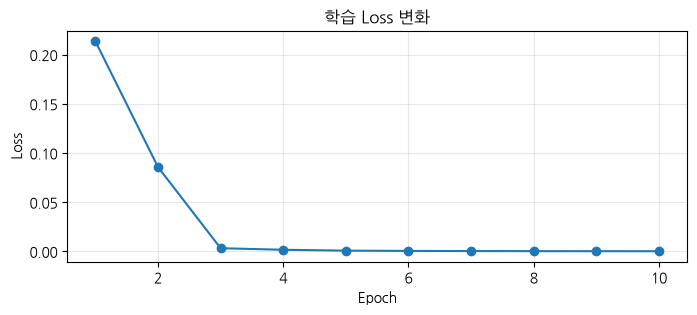

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(range(1, NUM_EPOCHS + 1), loss_history, marker='o')
plt.title('학습 Loss 변화')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

---
## STEP 6. 평가 - Accuracy & Confusion Matrix

학습이 끝난 모델을 **테스트 데이터**(학습에 사용하지 않은 데이터)로 평가합니다.

- **Accuracy** : 전체 중 몇 %를 올바르게 분류했는가
- **Confusion Matrix** : 실제 클래스 vs 예측 클래스를 표로 정리 → **어떤 클래스를 어떤 클래스로 헷갈렸는지** 확인 가능

⚠️ 현장에서는 단순 Accuracy보다 Confusion Matrix가 더 중요합니다.
- Outer Race(고장)를 Normal(정상)로 잘못 예측 → **고장을 놓침 (매우 위험)**
- Normal을 Outer Race로 잘못 예측 → 괜히 점검 (비용 낭비지만 안전)

### 📊 그런데, Accuracy만으로 충분할까?

오늘 데이터셋은 4개 클래스의 데이터 수가 비교적 균등합니다. 하지만 실제 현장에서는
대부분의 시간이 "정상" 상태이고, "고장" 데이터는 매우 드뭅니다.

예를 들어 정상 데이터가 99%, 고장 데이터가 1%인 상황에서 "무조건 정상"이라고만 예측해도
Accuracy는 99%가 됩니다. 즉, **전체 Accuracy가 높다고 해서 고장을 잘 잡아낸다는 뜻은 아닙니다.**

→ 이럴 때는 Confusion Matrix에서 **각 고장 클래스(행)별로 몇 %를 맞췄는지(재현율, Recall)**를
별도로 확인하는 것이 중요합니다. "전체 정확도"보다 "고장을 놓치지 않는 비율"이 현장에서는 더 중요한 지표입니다.

In [9]:
model.eval()  # 평가 모드 (학습용 기능 비활성화)

with torch.no_grad():  # 평가 시에는 기울기 계산이 필요 없음 → 메모리/속도 절약
    test_outputs = model(X_test_tensor.to(device))
    y_pred = test_outputs.argmax(dim=1).cpu().numpy()  # 점수가 가장 높은 클래스 선택

accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 Accuracy: {accuracy * 100:.2f}%")

테스트 Accuracy: 99.89%


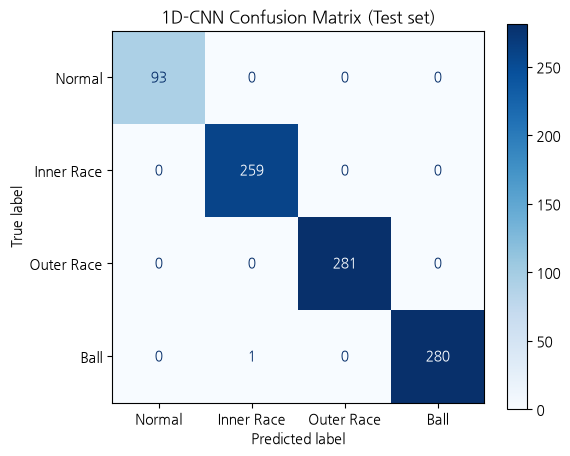

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    cmap='Blues',
    ax=ax,
)
plt.title('1D-CNN Confusion Matrix (Test set)')
plt.show()

> 👉 위 Confusion Matrix의 대각선(왼쪽 위 → 오른쪽 아래)이 "맞게 분류한 개수"입니다.
> CWRU 데이터셋은 클래스 간 신호 차이가 뚜렷해서, 대부분 **대각선에 모든 값이 모이는(=100% 정답)**
> 결과가 나옵니다.
>
> 만약 대각선 밖에 숫자가 있다면, 어떤 클래스를 어떤 클래스로 헷갈렸는지 확인해보세요.
> 특히 **고장(Inner/Outer/Ball)을 Normal로 잘못 예측한 칸**이 있다면,
> 실제 현장에서는 가장 위험한 오류(고장을 놓침)라는 점을 기억하세요.
> → 실제 공장 데이터는 노이즈가 더 많아서 이런 오류가 발생할 수 있고, 그때 Confusion Matrix가 중요해집니다.

---
## STEP 7. 모델 저장

학습된 모델의 가중치를 `.pt` 파일로 저장해두면, 나중에 다시 불러와서 사용할 수 있습니다.
세션 3(CNN-LSTM)에서 이 베이스라인과 성능을 비교하게 됩니다.

In [11]:
import os

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/cnn1d.pt')
print("저장 완료: models/cnn1d.pt")

저장 완료: models/cnn1d.pt


---
## STEP 8. 실습 - 전체 학습 파이프라인 함수로 묶기

지금까지의 과정을 정리하면:

```
데이터 준비 (X_train_tensor, y_train_tensor, ...)
      ↓
모델 정의 (CNN1D)
      ↓
Loss / Optimizer 설정
      ↓
학습 루프 (NUM_EPOCHS 반복)
      ↓
평가 (Accuracy, Confusion Matrix)
```

이 전체 과정을 **하나의 함수**로 묶어봅시다.
앞으로는 에폭 수나 모델을 바꿔도, 함수 호출 한 줄로 학습·평가가 끝나도록 합니다.

In [12]:
def train_and_evaluate(model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3):
    """
    주어진 모델을 학습시키고, 테스트 데이터로 평가한다.

    Parameters
    ----------
    model : 학습할 PyTorch 모델 (nn.Module)
    train_loader : 학습 데이터 DataLoader
    X_test_tensor, y_test : 테스트 입력(tensor)과 정답 레이블(numpy)
    num_epochs : 학습 에폭 수
    lr : learning rate

    Returns
    -------
    model        : 학습이 끝난 모델
    loss_history : 에폭별 평균 loss 리스트
    accuracy     : 테스트 Accuracy
    y_pred       : 테스트 데이터에 대한 예측 클래스
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor.to(device)).argmax(dim=1).cpu().numpy()
    accuracy = accuracy_score(y_test, y_pred)

    return model, loss_history, accuracy, y_pred

In [13]:
# 새 모델로 동일한 파이프라인을 한 번에 실행
torch.manual_seed(SEED)
new_model = CNN1D(num_classes=4)

trained_model, history, acc, preds = train_and_evaluate(
    new_model, train_loader, X_test_tensor, y_test, num_epochs=10, lr=1e-3
)

print(f"최종 Accuracy: {acc * 100:.2f}%")
print(f"최종 Loss: {history[-1]:.4f}")

최종 Accuracy: 99.67%
최종 Loss: 0.0001


---
## STEP 9. 생각해보기 - 이 모델, 다른 결함 크기에서도 통할까?

지금까지는 **같은 파일(같은 결함 크기, 같은 측정 회차)** 의 신호를 시간 순서대로 80% / 20%로 나눠
train/test로 사용했습니다. 그 결과 Accuracy는 거의 99%였습니다.

그런데 CWRU 데이터셋에는 같은 결함 종류라도 **결함 크기가 다른 파일**이 여러 개 있습니다.
(예: Inner Race → 007mil / 014mil / 021mil, 숫자가 클수록 더 큰 결함)

이번에는 다음과 같이 train/test를 나눠봅니다.

- **학습(train)**: 결함 크기 007mil, 014mil 데이터만 사용
- **평가(test)**: 학습 때 **한 번도 보지 못한** 021mil 데이터로 평가

👉 아래 셀을 실행하기 전에 먼저 예상해보세요. Accuracy가 지금까지처럼 99%와 비슷하게 나올까요,
아니면 달라질까요?

학습: 007mil + 014mil 결함 데이터 (3114개)
평가: 021mil 결함 데이터 - 학습 때 한 번도 보지 못한 결함 크기 (1515개)
Test Accuracy: 58.02%


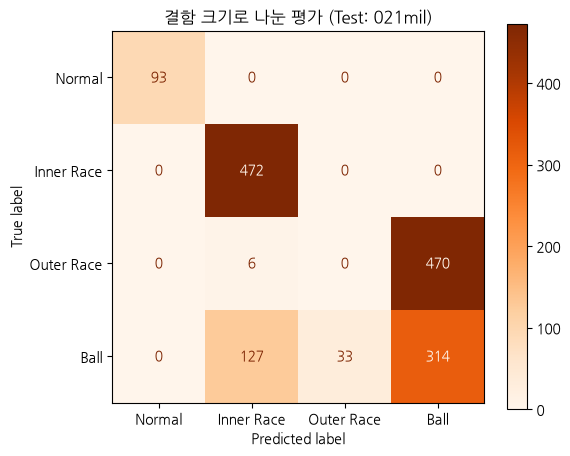

In [14]:
# 결함 크기(007mil / 014mil)로 학습하고, 처음 보는 결함 크기(021mil)로 평가해보기
fault_size_groups = {
    1: (['IR007_1_110.mat', 'IR014_1_175.mat'], 'IR021_1_214.mat'),
    2: (['OR007_6_1_136.mat', 'OR014_6_1_202.mat'], 'OR021_6_1_239.mat'),
    3: (['B007_1_123.mat', 'B014_1_190.mat'], 'B021_1_227.mat'),
}
normal_file = 'Time_Normal_1_098.mat'

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

# Normal: 파일이 1개뿐이라 지금까지와 동일하게 시간순 80/20으로 분리
normal_signal = get_de_signal(f'dataset/raw/{normal_file}')
normal_train, normal_test = train_test_split(normal_signal, train_size=0.8)
for seg in sliding_window(normal_train):
    X_train_list.append(compute_fft(seg))
    y_train_list.append(0)
for seg in sliding_window(normal_test):
    X_test_list.append(compute_fft(seg))
    y_test_list.append(0)

# 결함 클래스: 007mil + 014mil -> 학습 / 021mil(처음 보는 결함 크기) -> 평가
for label, (train_files, test_file) in fault_size_groups.items():
    for f in train_files:
        sig = get_de_signal(f'dataset/raw/{f}')
        for seg in sliding_window(sig):
            X_train_list.append(compute_fft(seg))
            y_train_list.append(label)
    sig = get_de_signal(f'dataset/raw/{test_file}')
    for seg in sliding_window(sig):
        X_test_list.append(compute_fft(seg))
        y_test_list.append(label)

X_train_sev = np.array(X_train_list)
X_test_sev = np.array(X_test_list)
y_train_sev = np.array(y_train_list)
y_test_sev = np.array(y_test_list)

# 정규화: train(007mil + 014mil) 기준으로만 fit
scaler_sev = StandardScaler()
X_train_sev_scaled = scaler_sev.fit_transform(X_train_sev)
X_test_sev_scaled = scaler_sev.transform(X_test_sev)

# DataLoader 구성
X_train_sev_tensor = torch.tensor(X_train_sev_scaled, dtype=torch.float32).unsqueeze(1)
y_train_sev_tensor = torch.tensor(y_train_sev, dtype=torch.long)
X_test_sev_tensor = torch.tensor(X_test_sev_scaled, dtype=torch.float32).unsqueeze(1)
train_loader_sev = DataLoader(TensorDataset(X_train_sev_tensor, y_train_sev_tensor), batch_size=BATCH_SIZE, shuffle=True)

# 동일한 CNN1D 구조로 학습 + 평가
torch.manual_seed(SEED)
sev_model = CNN1D(num_classes=4)
sev_model, sev_history, sev_acc, sev_preds = train_and_evaluate(
    sev_model, train_loader_sev, X_test_sev_tensor, y_test_sev, num_epochs=10, lr=1e-3
)

print(f"학습: 007mil + 014mil 결함 데이터 ({len(y_train_sev)}개)")
print(f"평가: 021mil 결함 데이터 - 학습 때 한 번도 보지 못한 결함 크기 ({len(y_test_sev)}개)")
print(f"Test Accuracy: {sev_acc * 100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_sev, sev_preds,
    display_labels=class_names,
    cmap='Oranges',
    ax=ax,
)
plt.title('결함 크기로 나눈 평가 (Test: 021mil)')
plt.show()

### 👉 결과 해석

Accuracy가 99%에서 크게 떨어진 것을 확인했나요? Confusion Matrix를 봐도 특정 클래스가
다른 클래스로 자주 잘못 분류되는 것을 볼 수 있습니다.

**왜 이런 일이 벌어질까?**

- 모델은 학습 데이터(007mil, 014mil)에 나타난 진동 패턴의 "크기(진폭)"와 "주파수 위치"를 기준으로
  클래스를 구분하는 법을 배웁니다.
- 결함 크기가 커지면(021mil) 충격 진동의 진폭과 주파수 성분의 분포가 함께 달라집니다.
  모델 입장에서는 "학습 때 본 것과는 다른 입력"이 들어온 셈입니다.
- 반면 STEP 1~8에서는 train/test가 **같은 파일(같은 결함 크기)** 이었기 때문에,
  모델이 이미 본 것과 거의 같은 분포의 데이터를 평가받아 99%가 나온 것입니다.

**현장에 적용할 때 시사점 (가장 중요!)**

"이 모델은 Accuracy 99%다"라는 결과만으로는 충분하지 않습니다. 다음을 함께 확인해야 합니다.

1. 이 99%는 **어떤 조건의 데이터**로 평가한 결과인가? (같은 설비? 같은 결함 크기? 같은 측정 시점?)
2. 우리 현장에 적용하려는 조건이, 학습/평가에 사용된 조건과 **얼마나 비슷한가**?
3. 조건이 다르다면, 실제 적용 전에 **그 조건의 데이터로 다시 검증**해봐야 한다.

→ 이렇게 "학습 때 본 조건"과 "실제 적용하는 조건"이 달라서 성능이 떨어지는 현상을
**분포 변화(Domain Shift)** 라고 부릅니다. 데이터팀이 "정확도 99%"라는 결과를 가져왔을 때,
